In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

#print(os.getcwd())

# Change the current working directory
os.chdir('/content/drive/MyDrive/Complete Machine Learning/Projects/Predictive Maintenance') # Write the current working directory as parameter

# Check the current working directory
#print(os.getcwd())

# List contents of the main directory (root directory)
!ls

 baseline_mlp.joblib
 F_test.csv
 F_train.csv
 logistics_dataset_with_maintenance_required.csv
 logistics_predictive_maintenanceV2.csv
 model_fp32.onnx
 model_int8.onnx
'Predictive Maintenance.ipynb'
 revised_logistics_dataset_V2.csv
 Untitled0.ipynb
 Validation_set.csv


In [4]:
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)

CSV = "logistics_predictive_maintenanceV2.csv"
df = pd.read_csv(CSV)
print("shape:", df.shape)

shape: (250000, 50)


In [5]:
# ---- column taxonomy: what is / isn't a fair model input --------------------
LABELS = ['Maintenance_Required', 'Maintenance_Severity', 'Maintenance_Severity_ID']

# engineered risk scores -> DERIVED from the label = leakage (free ~100% acc)
LEAKY_SCORES = ['PCR','UIR','TPI','MBF','ADS','OHI','CMES','UER','Predictive_Score','Pre_Event_Record']

# outcomes known only AFTER a maintenance event -> lookahead leakage
POST_EVENT = ['Maintenance_Cost','Historical_Maintenance_Cost','Downtime_Maintenance','Impact_on_Efficiency','Maintenance_Type']

# identifiers / free-text / dates -> not features
IDS = ['Vehicle_ID','Make_and_Model','Last_Maintenance_Date','Route_Info']

# federated-learning + split bookkeeping (used for FL/splitting, not as X)
FL_META = ['FL_Client_ID','Partition_Type','Local_Epochs_Per_Round','Communication_Rounds','Data_Split']

In [6]:
# everything else = legit on-board sensor / telemetry / usage / edge-context
used = list(set(LABELS + LEAKY_SCORES + POST_EVENT + IDS + FL_META))
FEATURES = list(df.drop(used, axis = 1).columns)
print("n_features:", len(FEATURES))

n_features: 23


In [7]:
print(FEATURES)

['Vehicle_Type', 'Year_of_Manufacture', 'Weather_Conditions', 'Road_Conditions', 'Communication_Interface', 'Telematics_Gateway', 'Edge_Device_Class', 'Usage_Hours', 'Load_Capacity', 'Actual_Load', 'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality', 'Failure_History', 'Anomalies_Detected', 'Diagnostic_Trouble_Code_Count', 'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', 'Days_Since_Last_Maintenance', 'Brake_Condition']


# Claude

               rows  pos_rate
FL_Client_ID                 
1             50172     0.067
2             24334     0.517
3             38184     0.290
4             62310     0.409


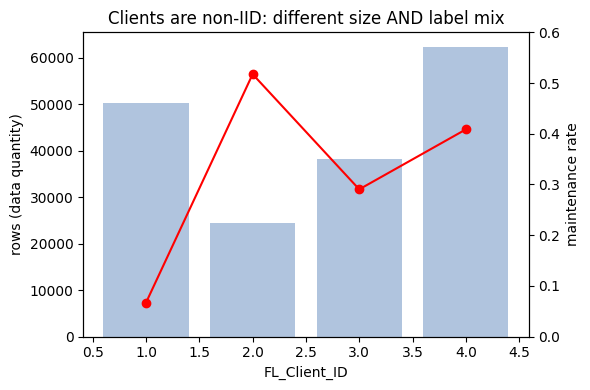

In [ ]:
# 1) NON-IID proof: each client's data quantity + label mix
c = train.groupby(df['FL_Client_ID'])['Maintenance_Required'].agg(rows='size', pos_rate='mean')
print(c.round(3))

fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.bar(c.index, c['rows'], color='lightsteelblue')
ax1.set_xlabel('FL_Client_ID'); ax1.set_ylabel('rows (data quantity)')

ax2 = ax1.twinx()
ax2.plot(c.index, c['pos_rate'], 'o-r')
ax2.set_ylabel('maintenance rate'); ax2.set_ylim(0, 0.6)

ax1.set_title('Clients are non-IID: different size AND label mix')

plt.tight_layout(); plt.show()

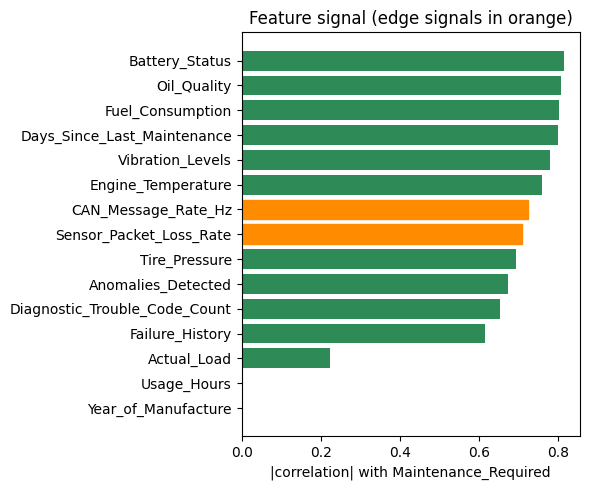

In [ ]:
# 2) which legit signals matter (edge metrics included)
corr = train[NUM].corrwith(train['Maintenance_Required']).abs().sort_values()
plt.figure(figsize=(6, 5))
bars = plt.barh(corr.index, corr.values, color='seagreen')
for i, name in enumerate(corr.index):            # highlight the two edge signals
    if name in ('CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate'):
        bars[i].set_color('darkorange')
plt.xlabel('|correlation| with Maintenance_Required')
plt.title('Feature signal (edge signals in orange)')
plt.tight_layout(); plt.show()

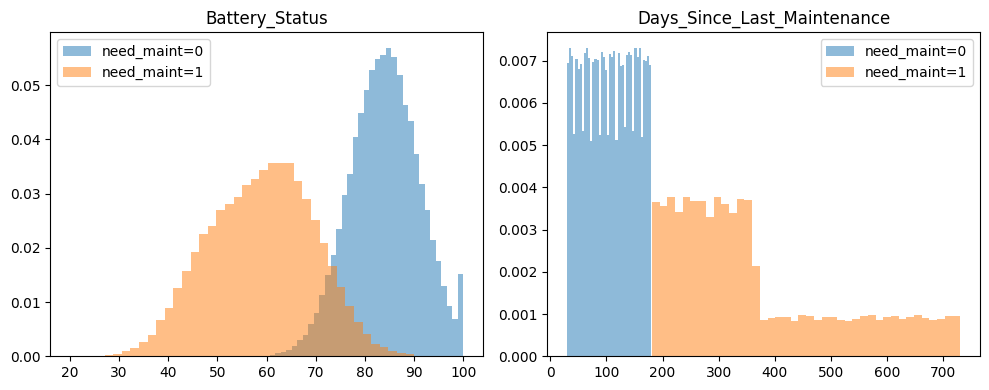

In [ ]:
# 3) class separation for two top signals
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['Battery_Status', 'Days_Since_Last_Maintenance']):
    for lab, sub in train.groupby('Maintenance_Required'):
        ax.hist(sub[col], bins=40, alpha=0.5, density=True, label=f'need_maint={lab}')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

<Axes: xlabel='Battery_Status', ylabel='Count'>

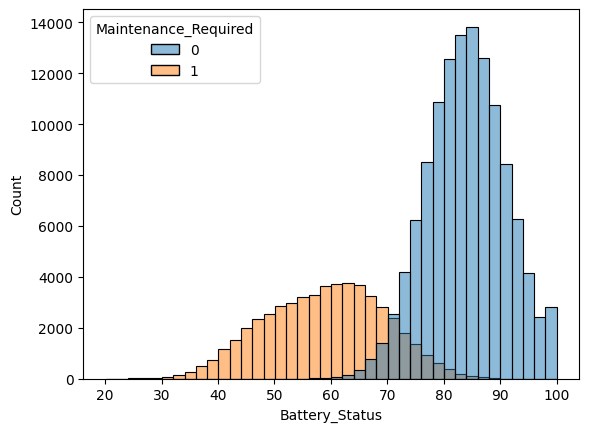

In [ ]:
sns.histplot(data=train, x='Battery_Status', hue='Maintenance_Required', bins=40,)

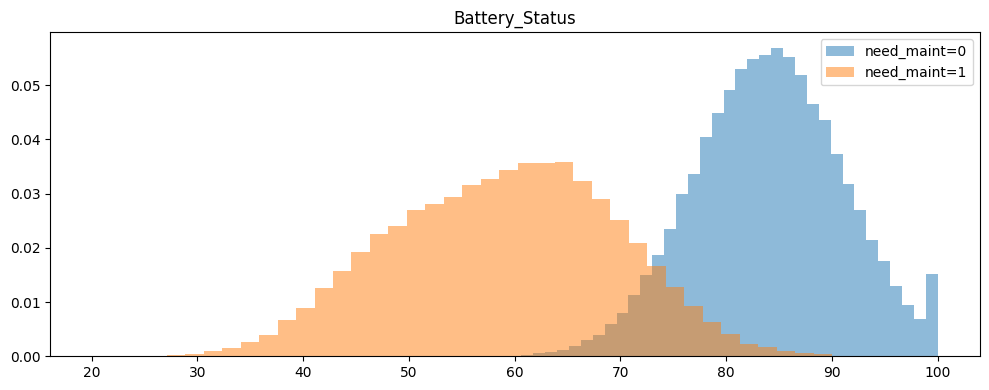

In [ ]:
fig, axes = plt.subplots(1, figsize=(10, 4))
for ax, col in zip([axes], ['Battery_Status']):
    for lab, sub in train.groupby('Maintenance_Required'):
        ax.hist(sub[col], bins=40, alpha=0.5, density=True, label=f'need_maint={lab}')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## Model training

In [9]:
from pandas.api.types import is_numeric_dtype
NUM = [c for c in FEATURES if is_numeric_dtype(df[c])]
CAT = [c for c in FEATURES if c not in NUM]   # categorical = "not numeric"

In [ ]:
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

tr = df[df['Data_Split'] == 'Train']
te = df[df['Data_Split'] == 'Test']
Xtr, ytr = tr[FEATURES], tr['Maintenance_Required']
Xte, yte = te[FEATURES], te['Maintenance_Required']

pre = ColumnTransformer([
    ('num', StandardScaler(), NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT),
])

# compact MLP on purpose — it has to fit on an edge device later
clf = Pipeline([
    ('pre', pre),
    ('mlp', MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu',
                          alpha=1e-4, max_iter=60, early_stopping=True,
                          n_iter_no_change=6, random_state=0)),
])
clf.fit(Xtr, ytr)

p = clf.predict_proba(Xte)[:, 1]
yhat = (p > 0.5).astype(int)
print("input dim:", pre.transform(Xtr[:1]).shape[1])
print("TEST ROC-AUC:", round(roc_auc_score(yte, p), 4))
print(classification_report(yte, yhat, digits=4))
print(confusion_matrix(yte, yhat))

joblib.dump(clf, "baseline_mlp.joblib")   # reused in Steps 4–6

input dim: 53
TEST ROC-AUC: 1.0
              precision    recall  f1-score   support

           0     1.0000    0.9999    1.0000     35000
           1     0.9999    1.0000    0.9999     15000

    accuracy                         1.0000     50000
   macro avg     0.9999    1.0000    1.0000     50000
weighted avg     1.0000    1.0000    1.0000     50000

[[34998     2]
 [    0 15000]]


['baseline_mlp.joblib']

In [ ]:
import numpy as np, time
from sklearn.metrics import accuracy_score, recall_score

pre, mlp = clf.named_steps['pre'], clf.named_steps['mlp']
Xp = pre.transform(Xte); Xp = (Xp.toarray() if hasattr(Xp, 'toarray') else Xp).astype(np.float32)
W = [w.astype(np.float32) for w in mlp.coefs_]
b = [x.astype(np.float32) for x in mlp.intercepts_]

def relu(x): return np.maximum(0, x)
def fwd(X, W, b):
    a = X
    for i in range(len(W) - 1): a = relu(a @ W[i] + b[i])
    return (1 / (1 + np.exp(-(a @ W[-1] + b[-1])))).ravel()

def q_int8(w):                                   # symmetric per-tensor PTQ
    s = max(np.abs(w).max() / 127.0, 1e-8)
    q = np.clip(np.round(w / s), -127, 127).astype(np.int8)
    return q, s

p32 = fwd(Xp, W, b)
Wq, sc = zip(*[q_int8(w) for w in W])
Wdq = [q.astype(np.float32) * s for q, s in zip(Wq, sc)]      # dequantized weights
p8  = fwd(Xp, Wdq, b)

for nm, p in [('fp32', p32), ('int8', p8)]:
    yh = (p > 0.5).astype(int)
    print(f"{nm}: acc={accuracy_score(yte,yh):.5f} recall_c1={recall_score(yte,yh):.5f}")
print("fp32 weight bytes:", sum(w.size for w in W)*4, "| int8 weight bytes:", sum(q.size for q in Wq))

fp32: acc=0.99996 recall_c1=1.00000
int8: acc=0.99996 recall_c1=1.00000
fp32 weight bytes: 8896 | int8 weight bytes: 2224


In [ ]:
#!pip install skl2onnx onnx onnxruntime
import os, numpy as np, onnxruntime as ort
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from onnxruntime.quantization import quantize_dynamic, QuantType

n_in = Xp.shape[1]                       # 47 — export ONLY the MLP; gateway assembles features
onx = convert_sklearn(mlp, initial_types=[('input', FloatTensorType([None, n_in]))],
                      target_opset=17, options={id(mlp): {'zipmap': False}})
open('model_fp32.onnx', 'wb').write(onx.SerializeToString())
quantize_dynamic('model_fp32.onnx', 'model_int8.onnx', weight_type=QuantType.QInt8)

def bench(path, X, y):
    s = ort.InferenceSession(path, providers=['CPUExecutionProvider'])
    nm = s.get_inputs()[0].name
    out = s.run(None, {nm: X.astype(np.float32)})
    prob = out[1][:, 1]                   # if this errors, print s.get_outputs() and adjust index
    acc = ((prob > 0.5).astype(int) == y).mean()
    import time; [s.run(None, {nm: X[:1].astype(np.float32)}) for _ in range(50)]
    t = time.time(); N = 3000
    for i in range(N): s.run(None, {nm: X[i:i+1].astype(np.float32)})
    return acc, (time.time() - t) / N * 1000

for tag, p in [('fp32', 'model_fp32.onnx'), ('int8', 'model_int8.onnx')]:
    a, ms = bench(p, Xp, yte); print(f"{tag}: KB={os.path.getsize(p)/1024:.1f} acc={a:.5f} lat={ms:.4f}ms")

fp32: KB=10.2 acc=0.99996 lat=0.0226ms
int8: KB=6.3 acc=0.99998 lat=0.0382ms
